In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [2]:
train_df = pd.read_csv("../processed_data/train.csv")
test_df = pd.read_csv("../processed_data/test.csv")

In [3]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,label
0,0.521569,0.333333,0.294118,0.572549,0.376471,0.333333,0.596078,0.392157,0.341176,0.603922,...,0.721569,0.537255,0.568627,0.741177,0.564706,0.607843,0.705882,0.537255,0.556863,5
1,0.952941,0.600000,0.623529,0.960784,0.603922,0.650980,0.933333,0.596078,0.631373,0.949020,...,0.843137,0.541176,0.470588,0.823529,0.533333,0.486274,0.839216,0.568627,0.498039,5
2,0.584314,0.474510,0.462745,0.611765,0.498039,0.505882,0.596078,0.478431,0.470588,0.580392,...,0.556863,0.411765,0.388235,0.552941,0.423529,0.403922,0.580392,0.454902,0.470588,0
3,0.745098,0.494118,0.580392,0.737255,0.474510,0.588235,0.725490,0.494118,0.572549,0.764706,...,0.737255,0.615686,0.603922,0.705882,0.572549,0.568627,0.737255,0.588235,0.592157,5
4,0.650980,0.541176,0.529412,0.643137,0.533333,0.521569,0.572549,0.439216,0.392157,0.556863,...,0.635294,0.482353,0.454902,0.631373,0.509804,0.490196,0.607843,0.486274,0.474510,5


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8012 entries, 0 to 8011
Columns: 12289 entries, 0 to label
dtypes: float64(12288), int64(1)
memory usage: 751.2 MB


In [5]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [6]:
X_train = X_train.reshape(-1, 64, 64, 3)
X_test = X_test.reshape(-1, 64, 64, 3)

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [9]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (8012, 64, 64, 3)
y_train: (8012, 7)
X_test: (2003, 64, 64, 3)
y_test: (2003, 7)


In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

C:\Users\krith\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 4.368593238822246, 1: 2.7848453249913105, 2: 1.3021290427433772, 3: 12.440993788819876, 4: 1.2860353130016051, 5: 0.21338020666879728, 6: 10.040100250626567}


In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.1692 - loss: 1.9214 - val_accuracy: 0.0325 - val_loss: 1.9452
Epoch 2/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.1031 - loss: 1.9617 - val_accuracy: 0.0325 - val_loss: 1.9471
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.1094 - loss: 1.9157 - val_accuracy: 0.1098 - val_loss: 1.9475
Epoch 4/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.2234 - loss: 1.9100 - val_accuracy: 0.0325 - val_loss: 1.9462
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.0893 - loss: 2.0017 - val_accuracy: 0.0325 - val_loss: 1.9435
Epoch 6/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.2110 - loss: 1.9098 - val_accuracy: 0.1113 - val_loss: 1.9442
Epoch 7/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.1728 - loss: 1.9279 - val_accuracy: 0.0325 - val_loss: 1.9436
Epoch 8/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.0517 - loss: 2.0393 - 

In [14]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

C:\Users\krith\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
import os
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split

In [17]:
BASE_DIR = "../dataset"
IMAGES_DIR = os.path.join(BASE_DIR, "all_images")
META_FILE = os.path.join(BASE_DIR, "HAM10000_metadata.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "ham10000_images")

TRAIN_DIR = os.path.join(OUTPUT_DIR, "train")
TEST_DIR = os.path.join(OUTPUT_DIR, "test")

In [18]:
df = pd.read_csv(META_FILE)

# Keep only required columns
df = df[['image_id', 'dx']]

print(df.head())
print("Total images:", len(df))

       image_id   dx
0  ISIC_0027419  bkl
1  ISIC_0025030  bkl
2  ISIC_0026769  bkl
3  ISIC_0025661  bkl
4  ISIC_0031633  bkl
Total images: 10015


In [19]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['dx'],
    random_state=42
)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

Training images: 8012
Testing images: 2003


In [20]:
classes = df['dx'].unique()

for cls in classes:
    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cls), exist_ok=True)

print("Class folders created successfully")

Class folders created successfully


In [21]:
import os

print(os.listdir(IMAGES_DIR))

['HAM10000_images_part_1', 'HAM10000_images_part_2']


In [22]:
def copy_images(dataframe, target_dir):
    count = 0
    subfolders = os.listdir(IMAGES_DIR)

    for _, row in dataframe.iterrows():
        for sub in subfolders:
            sub_path = os.path.join(IMAGES_DIR, sub)
            if not os.path.isdir(sub_path):
                continue

            for ext in [".jpg", ".JPG"]:
                img_name = row['image_id'] + ext
                src = os.path.join(sub_path, img_name)

                if os.path.exists(src):
                    dst = os.path.join(target_dir, row['dx'], img_name)
                    shutil.copy(src, dst)
                    count += 1
                    break
            else:
                continue
            break
    return count

In [23]:
train_count = copy_images(train_df, TRAIN_DIR)
print("Training images copied:", train_count)

Training images copied: 8012


In [24]:
test_count = copy_images(test_df, TEST_DIR)
print("Testing images copied:", test_count)

Testing images copied: 2003


In [25]:
for cls in os.listdir(TEST_DIR):
    print(cls, "->", len(os.listdir(os.path.join(TEST_DIR, cls))))

akiec -> 65
bcc -> 103
bkl -> 220
df -> 23
mel -> 223
nv -> 1341
vasc -> 28


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.


In [27]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [28]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze base model

In [29]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)

C:\Users\krith\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.6032 - loss: 1.3350 - val_accuracy: 0.6895 - val_loss: 0.8759
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.6840 - loss: 0.9365 - val_accuracy: 0.7064 - val_loss: 0.8166
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.6989 - loss: 0.8730 - val_accuracy: 0.7234 - val_loss: 0.7798
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.7095 - loss: 0.8139 - val_accuracy: 0.7179 - val_loss: 0.7623
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.7175 - loss: 0.7970 - val_accuracy: 0.7369 - val_loss: 0.7476
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.7397 - loss: 0.7323 - val_accuracy: 0.7354 - val_loss: 0.7566
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.7205 - loss: 0.7599 - val_accuracy: 0.7439 - val_loss: 0.7280
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.7462 - loss: 0.7214 - val_accu

In [32]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 917ms/step - accuracy: 0.7606 - loss: 0.6632
Test Accuracy: 75.69%


In [33]:
os.makedirs("../models", exist_ok=True)
model.save("../models/skin_disease_mobilenetv2.h5")

In [34]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [35]:
# True labels
y_true = test_generator.classes

# Predicted labels
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 875ms/step
              precision    recall  f1-score   support

       akiec       0.06      0.02      0.02        65
         bcc       0.05      0.03      0.04       103
         bkl       0.08      0.08      0.08       220
          df       0.00      0.00      0.00        23
         mel       0.11      0.12      0.12       223
          nv       0.67      0.72      0.69      1341
        vasc       0.00      0.00      0.00        28

    accuracy                           0.51      2003
   macro avg       0.14      0.14      0.14      2003
weighted avg       0.47      0.51      0.49      2003



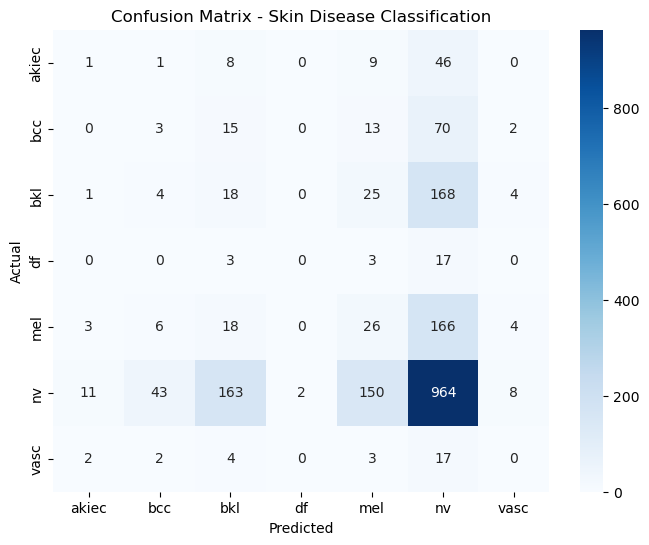

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Skin Disease Classification")
plt.show()

In [37]:
from tensorflow.keras.preprocessing import image
import numpy as np

class_names = list(train_generator.class_indices.keys())

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]

    return predicted_class

In [38]:
class_names = list(train_generator.class_indices.keys())
print(class_names)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [39]:
predict_image("../dataset/ham10000_images/test/mel/ISIC_0024700.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


'nv'

In [40]:
loss, accuracy = model.evaluate(test_generator, verbose=0)

print("📊 Final Model Performance")
print(f"➡ Test Accuracy : {accuracy*100:.2f} %")
print(f"➡ Test Loss     : {loss:.4f}")

📊 Final Model Performance
➡ Test Accuracy : 75.69 %
➡ Test Loss     : 0.6741


In [82]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_and_show(img_path):
    # Load and show image
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis("off")

    # Preprocess
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Title
    plt.title(f"Predicted Disease: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


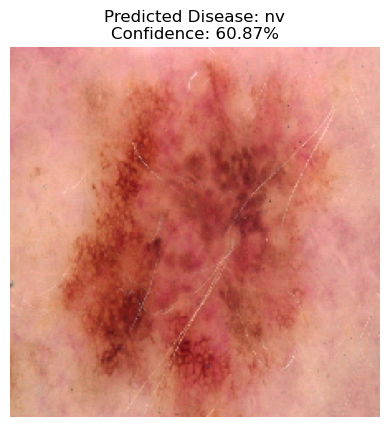

('nv', 60.87172031402588)

In [84]:
predict_and_show(
    "../dataset/ham10000_images/test/mel/ISIC_0024700.jpg"
)

In [86]:
loss, accuracy = model.evaluate(test_generator, verbose=0)

print("✅ Final Test Results")
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

✅ Final Test Results
Test Accuracy : 75.69%
Test Loss     : 0.6741


In [ ]:
import random

# Pick 5 random test images
filepaths = test_generator.filepaths
random_images = random.sample(filepaths, 5)

for img_path in random_images:
    predict_and_show(img_path)